In [12]:
import yaml
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

# --- Custom Utility Module ---
from mineral_utils import Paleodetector, slice_spectrum, detection_model_efficiency

print("Libraries imported successfully.")

Libraries imported successfully.


In [13]:
mineral_name =  "Apatite"  # Must match a key in MINERAL_LIBRARY

sample_mass_kg =  0.000001       # Sample mass in kg (e.g., 0.01 for 10g)

x_bins = np.linspace(0, 100000, 300)        #Track length bins in nm
x_mids = x_bins[:-1] + np.diff(x_bins) / 2

age = 5600.

In [14]:
CONFIG = yaml.safe_load(open('Data/basic_config.yaml', 'r'))
MINERAL_LIBRARY = yaml.safe_load(open('Data/mineral_library.yaml', 'r'))

In [15]:
scenario_config_simple = {
    'name': 'simple',
    'event_fluxes': {
        0.: ('H3a', 'H3a'),
        50.: ('H3a', 'H3a'),    }
}

In [16]:
# --- Setup & Verification ---
mineral_config = MINERAL_LIBRARY.get(mineral_name)
if not mineral_config:
    raise ValueError(f"Mineral '{mineral_name}' not found in MINERAL_LIBRARY.")

mineral = Paleodetector(mineral_config)

Initialized Paleodetector: Apatite


In [17]:
tracks = pd.read_csv("Data/inference_results/ARCI URAS26F2_obsidian_a066b033beta20.csv")
meas = tracks['len_um']*1000.
meas_hist, _ = np.histogram(meas, bins=x_bins)
median = np.median(meas)
left = median - np.quantile(meas, 0.167)
right = np.quantile(meas, 0.833) - median

In [18]:
total_fission_tracks = np.array(mineral.integrate_fission_spectrum(x_bins, age, sample_mass_kg))

Calculating spontaneous fission background...


In [19]:
track_spectrum = total_fission_tracks
sliced_large = slice_spectrum(x_bins, track_spectrum, bulk_etching_depth=1000, pit_width=4000., l_max_measurable=50000.)
read = detection_model_efficiency(x_bins, sliced_large, 0.66, 0.88, model_mean=median, sigma_left=left, sigma_right=right, meas_error=1000.)

Text(0.5, 1.0, 'Normalized observed vs theoretical fission track count in 25 cm2')

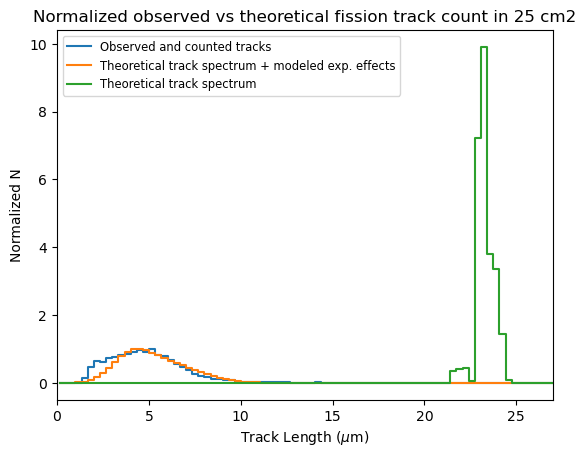

In [20]:
plt.step(x_mids/1000., meas_hist/meas_hist.max(), where='mid', label='Observed and counted tracks')
plt.step(x_mids/1000., read/read.max(), where='mid', label='Theoretical track spectrum + modeled exp. effects')
plt.step(x_mids/1000., track_spectrum/read.max(), where='mid', label='Theoretical track spectrum')
plt.xlim(0, 27)
plt.legend(fontsize='small', loc='upper left')
plt.xlabel(r"Track Length ($\mu$m)")
plt.ylabel(r"Normalized N")
plt.title(f"Normalized observed vs theoretical fission track count in 25 cm2")
